# Desarrollo del modelo XGBoost con nuevo etiquetado
---

# Configuración de ambiente

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
from sklearn.preprocessing import LabelEncoder, StandardScaler

import lightgbm as lgb

# Carga de modulos_apex
from modulos_apex_dev import DataExtractor_ccxt_v2 as ccxt, trading_backtester as tbt, detector_extremos_locales as eev

import os
from pathlib import Path
import sys
import warnings
warnings.filterwarnings("ignore")
np.set_printoptions(threshold=sys.maxsize)
pd.set_option(
    "display.max_rows", None, 
    "display.max_columns", None,
    "display.width", None,
    "display.max_colwidth", None,
    "display.precision", 1,
    "display.float_format" ,'{:,.4f}'.format)

CURRENT_DIR = os.getcwd()

# Carga de datos y variables
---


In [2]:
CURRENT_DIR

'/Users/julesaccm/Documents/Repos/Apex-project/notebooks'

In [20]:
# Cargamos los datos desde la carpeta data y si no existen, ejecutamos el pipeline
try: 
    os.chdir('..')
    os.chdir('data/processed')
    df_final = pd.read_csv('btc_data_target_v2.csv', index_col=0)
    print("Datos cargados desde 'data/processed/btc_data_target_v2.csv'")

except FileNotFoundError:
    print("Archivo no encontrado. Ejecutando el pipeline para generar los datos...")

    # 1. Instanciar la clase (Configuramos las variables globales del proceso)
    extractor_ccxt = ccxt.ExtractorDatosCCXT(
        exchange_id='binance', 
        symbol='BTC/USDT', 
        timeframe='1d'
    )

    # 2. Ejecutar las transformaciones en cadena (Pipeline)
    # Cada paso toma el DataFrame del paso anterior, lo transforma y lo devuelve

    # Paso A: Obtener el precio histórico y volumen
    btc = extractor_ccxt.obtener_datos(
        start_date="2017-01-01",
        end_date="2026-04-12",
        buffer_dias=34
    )

    # Paso B: Etiquetar máximos y mínimos (Nuestro Target)
    btc = eev.etiquetar_extremos_validados(btc, ventana_critica=7, smooth_poly=3)

    # Dividimos el target (extremo_tipo) para los modelos
    btc['target_max'] = np.where(btc['extremo_tipo']==1,1,0)
    btc['target_min'] = np.where(btc['extremo_tipo']==-1,1,0)

    # Quitamos columnas innecesarias
    btc = btc.drop(columns = 
                   ['Retorno_Log',
                    'extremo_tipo',
                    'extremo_validado',
                    'extremo_strength',
                    'extremo_precio',
                    'd1',
                    'd2',
                    'pct_change'])

    # Paso C: Calcular todo el análisis técnico
    btc_vars = extractor_ccxt.agregar_indicadores_avanzados(btc)

    # Paso D: Enriquecer con datos macroeconómicos
    df_final = extractor_ccxt.agregar_contexto_macro(btc_vars)

    # 3. Revisar el resultado final
    print("\n--- Vista previa de las primeras 5 filas ---")
    print(df_final.head())

    # Creamos el archivo en la carpeta data/processed
    os.chdir(CURRENT_DIR)
    os.chdir('..')
    os.makedirs('data/processed', exist_ok=True)
    df_final.to_csv('data/processed/btc_data_target_v2.csv', index=True)
    
    print("Datos generados y guardados en 'data/processed/btc_data_target_v2.csv'")

finally:
    os.chdir(CURRENT_DIR) 


Archivo no encontrado. Ejecutando el pipeline para generar los datos...
[CCXT] Descargando BTC/USDT desde 2016-11-28...
Iniciando descarga de datos macroeconómicos...
-> Descargando SP500 (^GSPC)...
-> Descargando DXY (DX-Y.NYB)...
-> Descargando Oro (GC=F)...

¡Contexto macro agregado exitosamente!

--- Vista previa de las primeras 5 filas ---
                 Open       High        Low      Close     Volume  target_max  \
Date                                                                            
2017-09-20 3,910.0400 4,046.0800 3,820.0000 3,900.0000   720.9351           0   
2017-09-21 3,889.9900 3,910.0000 3,567.0000 3,609.9900 1,001.6541           0   
2017-09-22 3,592.8400 3,750.0000 3,505.5500 3,595.8700   838.9664           0   
2017-09-23 3,595.8800 3,817.1900 3,542.9100 3,780.0000   752.7928           0   
2017-09-24 3,779.5400 3,789.9900 3,622.7600 3,660.0200   661.6364           0   

            target_min  RSI_14  BBL_20_2.0_2.0  BBM_20_2.0_2.0  \
Date               

In [23]:
df_final.sort_index().head()

,Open,High,Low,Close,Volume,target_max,target_min,RSI_14,BBL_20_2.0_2.0,BBM_20_2.0_2.0,BBU_20_2.0_2.0,BBB_20_2.0_2.0,BBP_20_2.0_2.0,Retorno_1d,Volumen_Relativo,STOCHk_9_6_3,STOCHd_9_6_3,STOCHh_9_6_3,STOCHRSIk_14_14_3_3,STOCHRSId_14_14_3_3,MACD_12_26_9,MACDh_12_26_9,MACDs_12_26_9,ADX_14,ADXR_14_2,DMP_14,DMN_14,WILLR_14,CCI_14_0.015,ATRr_14,ROC_10,BULLP_13,BEARP_13,UO_7_14_28,SP500_Close,DXY_Close,Oro_Close,SP500_Retorno,DXY_Retorno,Oro_Retorno
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2017-09-20,"3,910.0400","4,046.0800","3,820.0000","3,900.0000",720.9351,0,0,42.1122,"3,343.4326","4,136.5980","4,929.7634",38.3487,0.3509,-0.0026,0.7462,71.7138,50.5531,21.1607,88.5350,80.2284,-134.0219,-26.5041,-107.5178,56.7522,57.7379,12.5209,32.6198,-45.0697,"2,912.1048",413.0069,-5.5775,92.2884,-133.7916,52.7056,"2,508.2400",92.5100,"1,312.0000",0.0006,0.0078,0.0044
2017-09-21,"3,889.9900","3,910.0000","3,567.0000","3,609.9900","1,001.6541",0,0,37.5333,"3,321.0054","4,075.3520","4,829.6986",37.0199,0.1915,-0.0744,1.0136,65.5817,57.3124,8.2693,79.0397,82.5939,-150.5189,-34.4008,-116.1180,56.2533,56.9730,11.7691,35.0903,-58.6638,"2,570.6837",408.0064,-14.2208,5.3229,-337.6771,56.6842,"2,500.6001",92.2600,"1,290.6000",-0.0030,-0.0027,-0.0163
2017-09-22,"3,592.8400","3,750.0000","3,505.5500","3,595.8700",838.9664,0,0,37.3206,"3,272.4526","4,031.5385","4,790.6244",37.6574,0.2130,-0.0039,0.8528,62.3628,62.5359,-0.1732,72.3493,79.9747,-162.8549,-37.3895,-125.4654,55.8767,56.3144,11.2506,34.6518,-51.6116,"2,498.1403",396.3238,-13.6380,-110.5618,-355.0118,49.3156,"2,502.2200",92.1700,"1,293.3000",0.0006,-0.0010,0.0021
2017-09-23,"3,595.8800","3,817.1900","3,542.9100","3,780.0000",752.7928,0,0,41.9425,"3,263.0144","3,995.0845","4,727.1546",36.6485,0.3531,0.0512,0.7629,64.0549,65.0756,-1.0207,73.5258,74.9716,-155.9755,-24.4081,-131.5674,55.2291,55.7412,11.9201,32.9003,-38.9575,"2,508.5021",387.6064,-4.1750,-31.8630,-306.1430,52.6023,"2,502.2200",92.1700,"1,293.3000",0.0000,0.0000,0.0000
2017-09-24,"3,779.5400","3,789.9900","3,622.7600","3,660.0200",661.6364,0,0,39.8789,"3,227.9618","3,973.0800","4,718.1982",37.5083,0.2899,-0.0317,0.6963,54.1243,64.1590,-10.0347,77.3866,74.4206,-158.3793,-21.4495,-136.9298,54.6277,55.2522,11.5372,31.8435,-46.5628,"2,423.3298",371.8652,14.7694,-32.0583,-199.2883,48.3708,"2,502.2200",92.1700,"1,293.3000",0.0000,0.0000,0.0000


In [28]:
df_final.tail()

,Open,High,Low,Close,Volume,target_max,target_min,RSI_14,BBL_20_2.0_2.0,BBM_20_2.0_2.0,BBU_20_2.0_2.0,BBB_20_2.0_2.0,BBP_20_2.0_2.0,Retorno_1d,Volumen_Relativo,STOCHk_9_6_3,STOCHd_9_6_3,STOCHh_9_6_3,STOCHRSIk_14_14_3_3,STOCHRSId_14_14_3_3,MACD_12_26_9,MACDh_12_26_9,MACDs_12_26_9,ADX_14,ADXR_14_2,DMP_14,DMN_14,WILLR_14,CCI_14_0.015,ATRr_14,ROC_10,BULLP_13,BEARP_13,UO_7_14_28,SP500_Close,DXY_Close,Oro_Close,SP500_Retorno,DXY_Retorno,Oro_Retorno
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2026-04-08,"71,924.2200","72,857.0000","70,707.2300","71,069.9300","19,802.6863",0,0,56.2219,"64,930.2312","68,647.3795","72,364.5278",10.8297,0.8259,-0.0119,1.1059,78.3761,61.0119,17.3643,88.7848,82.6817,-22.1475,439.6265,-461.7740,14.4628,14.1044,26.1859,17.7555,-22.7449,"68,086.5977","2,575.0485",7.6639,"3,800.6314","1,650.8614",55.5082,"6,782.8101",99.1300,"4,749.5000",0.0251,-0.0051,0.0198
2026-04-09,"71,069.9300","73,145.0000","70,466.0000","71,787.9700","18,158.4216",0,0,58.1578,"64,819.5140","68,711.2415","72,602.9690",11.3278,0.8953,0.0101,1.0140,81.6200,68.9537,12.6662,92.8152,90.4561,194.7324,525.2051,-330.4727,14.9110,14.5052,25.0421,16.4398,-16.6609,"68,771.8837","2,582.4736",7.4713,"3,698.4026","1,019.4026",57.2356,"6,824.6602",98.8200,"4,792.2002",0.0062,-0.0031,0.0090
2026-04-10,"71,787.9800","73,434.0000","71,426.1500","72,962.7000","17,372.6329",0,0,61.1821,"64,581.0834","68,913.4705","73,245.8576",12.5734,0.9673,0.0164,0.9595,83.5425,76.7130,6.8295,92.8152,91.4718,456.1441,629.2934,-173.1493,15.4422,14.9525,24.4412,15.5121,-5.5881,"70,100.6661","2,541.4291",6.8511,"3,485.1023","1,477.2523",59.9376,"6,816.8901",98.6500,"4,761.8999",-0.0011,-0.0017,-0.0063
2026-04-11,"72,962.7100","73,790.0000","72,513.0900","73,043.1600","9,070.9437",1,0,61.3880,"64,499.0313","69,172.6785","73,846.3257",13.5130,0.9141,0.0011,0.5091,88.5641,81.6130,6.9510,98.0951,94.5752,662.1740,668.2587,-6.0847,16.0812,15.4961,24.5691,14.9349,-8.4965,"70,882.1881","2,451.1063",7.2368,"3,399.0648","2,122.1548",58.9688,"6,816.8901",98.6500,"4,761.8999",0.0000,0.0000,0.0000
2026-04-12,"73,043.1600","73,137.2400","70,505.8800","70,740.9800","13,472.4680",0,0,52.7656,"64,503.1112","69,164.4050","73,825.6988",13.4789,0.6691,-0.0315,0.7890,80.4913,82.8624,-2.3710,84.6351,91.8485,632.3976,510.7858,121.6118,15.4527,15.4474,22.6950,19.6143,-37.7453,"69,211.3719","2,463.9815",5.7382,"2,696.2984",64.9384,50.4068,"6,816.8901",98.6500,"4,761.8999",0.0000,0.0000,0.0000


In [24]:
df_final.shape

(3127, 40)

In [27]:
print(df_final['target_max'].value_counts(dropna=False),"\n",df_final['target_max'].value_counts(dropna=False, normalize=True))

print(df_final['target_min'].value_counts(dropna=False),"\n",df_final['target_min'].value_counts(dropna=False, normalize=True))


target_max
0    3044
1      83
Name: count, dtype: int64 
 target_max
0   0.9735
1   0.0265
Name: proportion, dtype: float64
target_min
0    3045
1      82
Name: count, dtype: int64 
 target_min
0   0.9738
1   0.0262
Name: proportion, dtype: float64


# Preparación de datos de entrenamiento, evaluación y OoT
---
Considerar la purga para evitar data leakage

In [9]:
# --- 1. CONFIGURACIÓN DE FEATURES ---
df_apex = df_final.copy()

# Excluimos los precios crudos de BTC, el Target y los precios crudos macroeconómicos
columnas_excluir = [
    'Open', 'High', 'Low', 'Close', 'Volume', 'Target',
    'SP500_Close', 'DXY_Close', 'Oro_Close' # ¡Importante! Solo queremos sus retornos
    , 'Retorno_Log'
]

# Creamos la lista final de features (X)
features = [col for col in df_apex.columns if col not in columnas_excluir]

# --- 2. PREPARACIÓN DE DATOS (Train / Test) ---
X = df_apex[features]
y = df_apex['Target']

# División cronológica (80% Train, 20% Test)
split_idx = int(len(df_apex) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Entrenando con {len(features)} variables (Técnicas + Macro)...")
print(f"Días de entrenamiento: {len(X_train)} | Días de prueba: {len(X_test)}")

# Traducir las etiquetas (-1, 0, 1) a formato XGBoost (0, 1, 2)
le = LabelEncoder()
y_train_xgb = le.fit_transform(y_train)
y_test_xgb = le.transform(y_test)

Entrenando con 30 variables (Técnicas + Macro)...
Días de entrenamiento: 585 | Días de prueba: 147


In [10]:
# 5. Recuperamos la porción de "Test" pero del DataFrame original (que SÍ tiene 'Close')
split_idx = int(len(df_apex) * 0.8)
df_test_completo = df_apex.iloc[split_idx:].copy()


# Selección de variables
---

La selección de las variables se empleará sobre el conjunto completo de datos.

## Análisis de correlación

In [11]:
df_apex[features].describe().T

,count,mean,std,min,25%,50%,75%,max
RSI_14,732.0,52.953983,12.285040,22.795101,44.314218,51.536931,61.409751,87.344142
BBL_20_2.0_2.0,732.0,76849.430175,22019.406384,38040.164608,58607.810618,78402.211931,95242.132282,116631.100344
BBM_20_2.0_2.0,732.0,83197.847209,22446.139491,41818.085500,63397.653000,85177.215500,102345.161375,118285.325500
BBU_20_2.0_2.0,732.0,89546.264243,23247.377406,44105.914199,70196.966278,92992.206642,109841.965978,128328.095957
BBB_20_2.0_2.0,732.0,15.978537,7.806692,2.797008,10.334874,14.432985,18.505979,46.881697
BBP_20_2.0_2.0,732.0,0.528656,0.320670,-0.401966,0.291934,0.532692,0.785490,1.297922
Retorno_1d,732.0,0.001324,0.024985,-0.085387,-0.011326,0.000708,0.012844,0.118834
Volumen_Relativo,732.0,1.001234,0.535321,0.181103,0.631265,0.916056,1.250731,4.765437
STOCHk_9_6_3,732.0,55.941322,25.363565,6.444626,33.259361,58.100298,80.673742,95.754743
STOCHd_9_6_3,732.0,55.931867,21.858111,11.162893,37.751367,57.337916,73.097332,93.300036


In [12]:
scaler = StandardScaler()
features_df_std = pd.DataFrame(scaler.fit_transform(df_apex[features]), columns=features, index=df_apex.index)
features_df_std.describe().T

,count,mean,std,min,25%,50%,75%,max
RSI_14,732.0,-3.882747e-16,1.000684,-2.456606,-0.703756,-0.115427,0.688769,2.801267
BBL_20_2.0_2.0,732.0,2.329648e-16,1.000684,-1.763708,-0.829000,0.070567,0.835866,1.807899
BBM_20_2.0_2.0,732.0,6.212396e-16,1.000684,-1.844774,-0.882723,0.088243,0.853617,1.564254
BBU_20_2.0_2.0,732.0,-3.882747e-16,1.000684,-1.955981,-0.832891,0.148331,0.873629,1.669365
BBB_20_2.0_2.0,732.0,3.300335e-16,1.000684,-1.689646,-0.723421,-0.198113,0.323975,3.961254
BBP_20_2.0_2.0,732.0,-1.164824e-16,1.000684,-2.904103,-0.738717,0.012593,0.801476,2.400572
Retorno_1d,732.0,-9.706868e-18,1.000684,-3.472926,-0.506679,-0.024675,0.461369,4.706475
Volumen_Relativo,732.0,-1.892839e-16,1.000684,-1.533084,-0.691590,-0.159225,0.466389,7.036488
STOCHk_9_6_3,732.0,1.747236e-16,1.000684,-1.952822,-0.894885,0.085179,0.975783,1.570782
STOCHd_9_6_3,732.0,-3.882747e-17,1.000684,-2.049563,-0.832319,0.064370,0.785850,1.710748


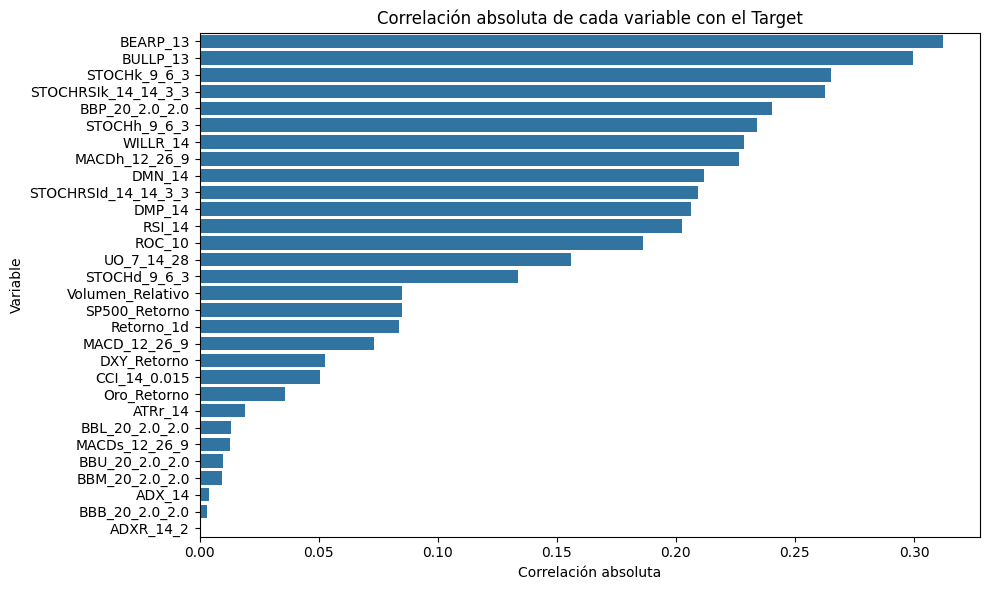

In [13]:
feature_corr = features_df_std.corrwith(df_apex['Target'], method='spearman')
sort_corr = feature_corr.abs().sort_values(ascending=False).to_frame().reset_index()
sort_corr.columns = ['Variable', 'Correlación']

plt.figure(figsize=(10, 6))
sns.barplot(x='Correlación', y='Variable', data=sort_corr)
plt.title('Correlación absoluta de cada variable con el Target')
plt.xlabel('Correlación absoluta')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()


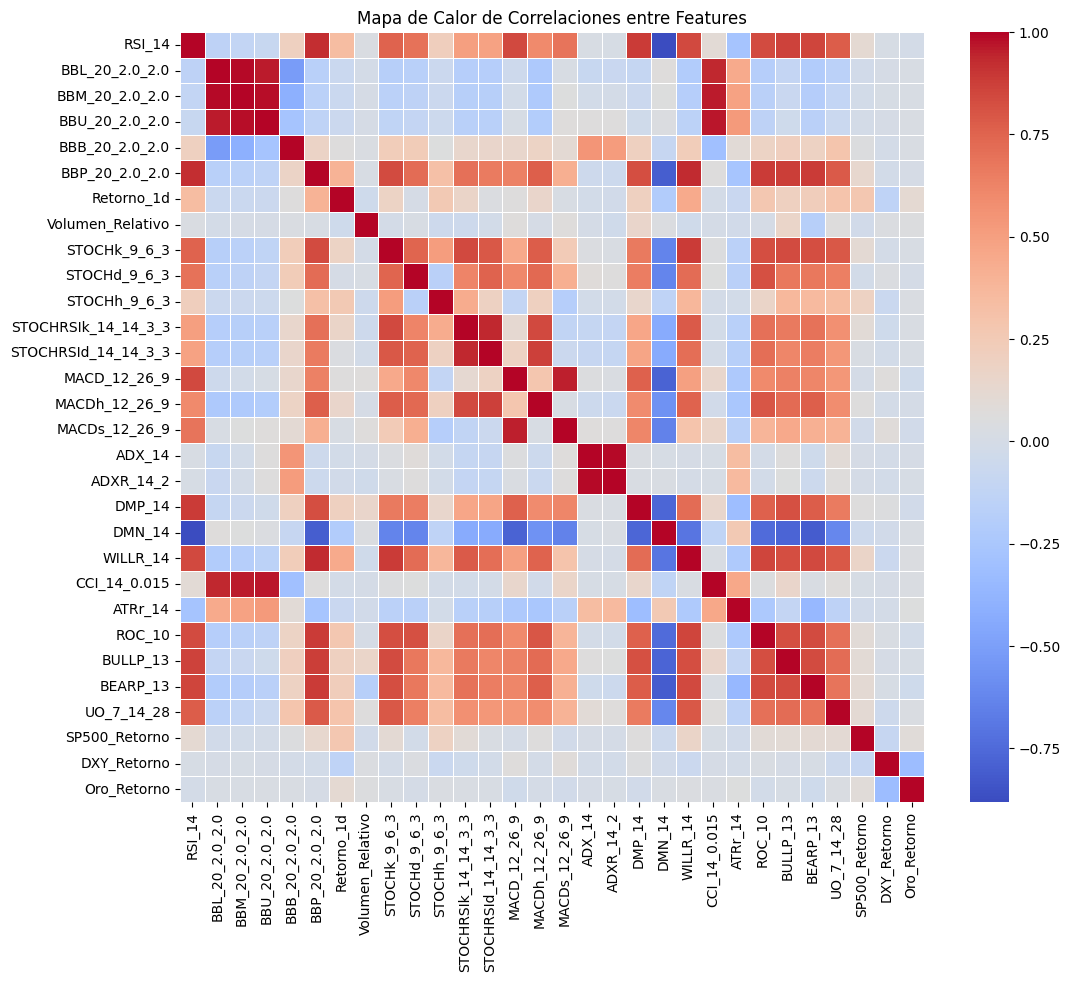

In [14]:
# Correlación entre variables
plt.figure(figsize=(12, 10))
sns.heatmap(features_df_std.corr('spearman'), annot=False, cmap='coolwarm', linewidths=0.5)
plt.title("Mapa de Calor de Correlaciones entre Features")
plt.show()

In [15]:
# Top 15 variables más correlacionadas con el Target
target_top15_corr = sort_corr.head(15)['Variable'].tolist()
print(f"TOP 15 variables más correlacionadas con el Target: \n{target_top15_corr}")

TOP 15 variables más correlacionadas con el Target: 
['BEARP_13', 'BULLP_13', 'STOCHk_9_6_3', 'STOCHRSIk_14_14_3_3', 'BBP_20_2.0_2.0', 'STOCHh_9_6_3', 'WILLR_14', 'MACDh_12_26_9', 'DMN_14', 'STOCHRSId_14_14_3_3', 'DMP_14', 'RSI_14', 'ROC_10', 'UO_7_14_28', 'STOCHd_9_6_3']


In [16]:
from modulos_apex_dev.correlated_vars_selector import highly_correlated_vars as hcv

In [17]:
# Dataframe con las variables más correlacionadas con otras variables (Posibles redundancias)
feature_corr_matrix = features_df_std.corr('spearman').abs()

pares_feature = []
# Tomamos solo la parte superior de la matriz de correlacion para evitar duplicados (i,j) y (j,i)
for i in range(len(features)):
    for j in range(i+1, len(features)):
        if feature_corr_matrix.iloc[i, j] > 0.7:
            pares_feature.append((features[i], features[j], feature_corr_matrix.iloc[i, j]))

pares_feature_df = pd.DataFrame(pares_feature, columns=['Variable_1', 'Variable_2', 'Correlacion_mayor_0.7'])
pares_feature_df = pares_feature_df.merge(
    sort_corr,
    left_on='Variable_2',
    right_on='Variable',
    how='left'
).drop(columns=['Variable']).rename(columns={'Correlación':'corr_var2_target'}) \
.merge(
    sort_corr,
    left_on='Variable_1',
    right_on='Variable',
    how='left'
).drop(columns=['Variable']).rename(columns={'Correlación':'corr_var1_target'}) \
    .sort_values(by=['Variable_1','corr_var2_target'], ascending=[True, False])

pares_feature_df['rank'] = pares_feature_df.groupby(['Variable_1'])['corr_var2_target'].rank(method='first', ascending=False)

# pares_feature_df['flag_test'] = np.where(
#     (pares_feature_df['corr_var1_target']<=pares_feature_df['corr_var2_target'])
#     & (pares_feature_df['rank']==1),
#     pares_feature_df['Variable_2'],
#     pares_feature_df['Variable_1'])

print(pares_feature_df)

features_redundantes = set(pares_feature_df['Variable_1'].unique()).union(set(pares_feature_df['Variable_2'].unique()))
print(f"Variables potencialmente redundantes (correlación > 0.7): {len(features_redundantes)}\n{features_redundantes}")

features_no_redundantes = [feat for feat in features if feat not in features_redundantes]
print(f"\nVariables no redundantes (correlación <= 0.7): {len(features_no_redundantes)}\n{features_no_redundantes}")


        Variable_1      Variable_2  Correlacion_mayor_0.7  corr_var2_target  \
54          ADX_14       ADXR_14_2               0.991740          0.000750   
12  BBL_20_2.0_2.0    CCI_14_0.015               0.937144          0.050789   
11  BBL_20_2.0_2.0  BBU_20_2.0_2.0               0.956077          0.009819   
10  BBL_20_2.0_2.0  BBM_20_2.0_2.0               0.989380          0.009265   
14  BBM_20_2.0_2.0    CCI_14_0.015               0.958606          0.050789   
..             ...             ...                    ...               ...   
27    STOCHk_9_6_3    STOCHd_9_6_3               0.748177          0.133748   
65        WILLR_14        BEARP_13               0.844915          0.312108   
64        WILLR_14        BULLP_13               0.827112          0.299379   
63        WILLR_14          ROC_10               0.858384          0.186144   
66        WILLR_14      UO_7_14_28               0.791766          0.155884   

    corr_var1_target  rank  
54          0.003802  

In [18]:
high_corr_vars = hcv(features_df_std, sort_corr, 'Correlación', 0.7)

Seleccion por criterio externo: iteración 29
Seleccion por criterio externo: iteración 28
Seleccion por criterio externo: iteración 27
Seleccion por criterio externo: iteración 26
Seleccion por criterio externo: iteración 25
Seleccion por criterio externo: iteración 24
Seleccion por criterio externo: iteración 23
Seleccion por criterio externo: iteración 22
Seleccion por criterio externo: iteración 21
Seleccion por criterio externo: iteración 20
Seleccion por criterio externo: iteración 19
Seleccion por criterio externo: iteración 18
Seleccion por criterio externo: iteración 17
Seleccion por criterio externo: iteración 16
Seleccion por criterio externo: iteración 15
Seleccion por criterio externo: iteración 14
Proceso finalizado.


In [19]:
high_target_corr_no_redundant = [var for var in features if var not in high_corr_vars]

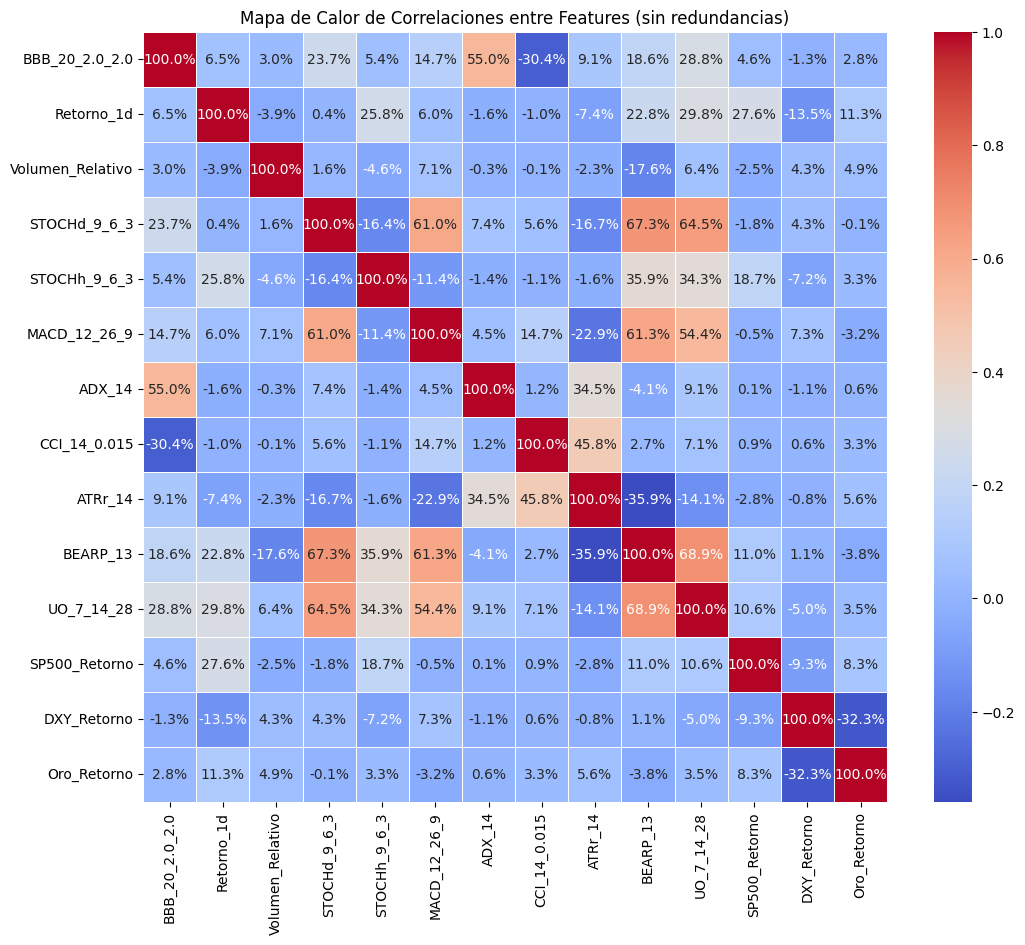

In [20]:
# Correlación entre variables depurando las redundantes
plt.figure(figsize=(12, 10))
sns.heatmap(features_df_std[high_target_corr_no_redundant].corr('spearman'), annot=True, fmt=".1%", cmap='coolwarm', linewidths=0.5)
plt.title("Mapa de Calor de Correlaciones entre Features (sin redundancias)")
plt.show()

Para la selección de variables se tienen dos propuestas:
1. Una propuesta es considerar, de las variables potencialmente redundantes, la de mayor correlación con la variable objetivo.

2. Otra propuesta es evaluar las variables no redundantes e ir probando el backtesting de las redundantes una por una y seleccionar el conjunto con mejor retorno.

## Definición de algoritmo de selección

In [21]:
def feature_selection_algorithm(
        features_list: list, 
        X_train, y_train_xgb, 
        X_test, y_test_xgb) -> pd.DataFrame:
    """
    Algoritmo de selección de variables.

    El objetivo de esta función entrenar un modelo XGBoost con cada una de 
    las variables _features_list_ para obtener su importancia (gain).

    Args:
        features_list (list): Lista con las variables.
        X_train (DataFrame): Conjunto de entrenamiento con las variables.
        y_train_xgb (array): Etiquetas de entrenamiento codificadas para XGBoost.
        X_test (DataFrame): Conjunto de prueba con las variables.
        y_test_xgb (array): Etiquetas de prueba codificadas para XGBoost

    Returns:
        DataFrame con las variables y su importancia (gain).
    """
    # 1. Librerias necesarias
    import xgboost as xgb
    import numpy as np

    # 2. Inicialización del modelo
    modelo_tuning = xgb.XGBClassifier(
        max_depth=5,
        learning_rate=0.005,
        subsample=0.7,
        gamma=0.117266,
        n_estimators=100,
        scale_pos_weight=4.15615,
        early_stopping_rounds=50, # Tu recomendación aplicada
        random_state=42,
        n_jobs=-1
    )
            
    _resultados = []
    
    for f in features_list:
        print(f"Evaluando variable: {f}")

        # Entrenamos pasándole el conjunto de prueba para el Early Stopping
        modelo_tuning.fit(
            X_train[[f]], y_train_xgb,
            eval_set=[(X_test[[f]], y_test_xgb)],
            verbose=False
        )

        # Obtenemos la importancia de la varibale f
        importancia_f = modelo_tuning.get_booster().get_score(importance_type='gain').get(f,0)

        _resultados.append((f, importancia_f))

    # Consolidamos los resultados en un DataFrame    
    _df_resultados = pd.DataFrame(_resultados, columns=['variable','importancia_gain'])
    _df_resultados = _df_resultados.sort_values(by='importancia_gain', ascending=False).reset_index(drop=True)

    return _df_resultados


In [22]:
# Ejecución del algoritmo de selección de variables

features_importance = feature_selection_algorithm(
    features_list=features,
    X_train=X_train, y_train_xgb=y_train_xgb,
    X_test=X_test, y_test_xgb=y_test_xgb,
    )
    

Evaluando variable: RSI_14
Evaluando variable: BBL_20_2.0_2.0
Evaluando variable: BBM_20_2.0_2.0
Evaluando variable: BBU_20_2.0_2.0
Evaluando variable: BBB_20_2.0_2.0
Evaluando variable: BBP_20_2.0_2.0
Evaluando variable: Retorno_1d
Evaluando variable: Volumen_Relativo
Evaluando variable: STOCHk_9_6_3
Evaluando variable: STOCHd_9_6_3
Evaluando variable: STOCHh_9_6_3
Evaluando variable: STOCHRSIk_14_14_3_3
Evaluando variable: STOCHRSId_14_14_3_3
Evaluando variable: MACD_12_26_9
Evaluando variable: MACDh_12_26_9
Evaluando variable: MACDs_12_26_9
Evaluando variable: ADX_14
Evaluando variable: ADXR_14_2
Evaluando variable: DMP_14
Evaluando variable: DMN_14
Evaluando variable: WILLR_14
Evaluando variable: CCI_14_0.015
Evaluando variable: ATRr_14
Evaluando variable: ROC_10
Evaluando variable: BULLP_13
Evaluando variable: BEARP_13
Evaluando variable: UO_7_14_28
Evaluando variable: SP500_Retorno
Evaluando variable: DXY_Retorno
Evaluando variable: Oro_Retorno


In [23]:
features_importance

,variable,importancia_gain
0,Volumen_Relativo,1.344316
1,BEARP_13,1.312027
2,DMN_14,0.987106
3,BULLP_13,0.985501
4,STOCHRSId_14_14_3_3,0.965988
5,Retorno_1d,0.950012
6,RSI_14,0.917745
7,DXY_Retorno,0.895233
8,WILLR_14,0.891608
9,SP500_Retorno,0.886614


In [24]:
high_corr_vars_gain = hcv(features_df_std, features_importance.rename(columns={'variable':'Variable'}, inplace=True), 'importancia_gain', 0.7)
high_gain_no_redundant = [var for var in features if var not in high_corr_vars_gain]

Seleccion por correlacion media: iteración 29
Seleccion por correlacion media: iteración 28
Seleccion por correlacion media: iteración 27
Seleccion por correlacion media: iteración 26
Seleccion por correlacion media: iteración 25
Seleccion por correlacion media: iteración 24
Seleccion por correlacion media: iteración 23
Seleccion por correlacion media: iteración 22
Seleccion por correlacion media: iteración 21
Seleccion por correlacion media: iteración 20
Seleccion por correlacion media: iteración 19
Seleccion por correlacion media: iteración 18
Seleccion por correlacion media: iteración 17
Seleccion por correlacion media: iteración 16
Seleccion por correlacion media: iteración 15
Seleccion por correlacion media: iteración 14
Proceso finalizado.


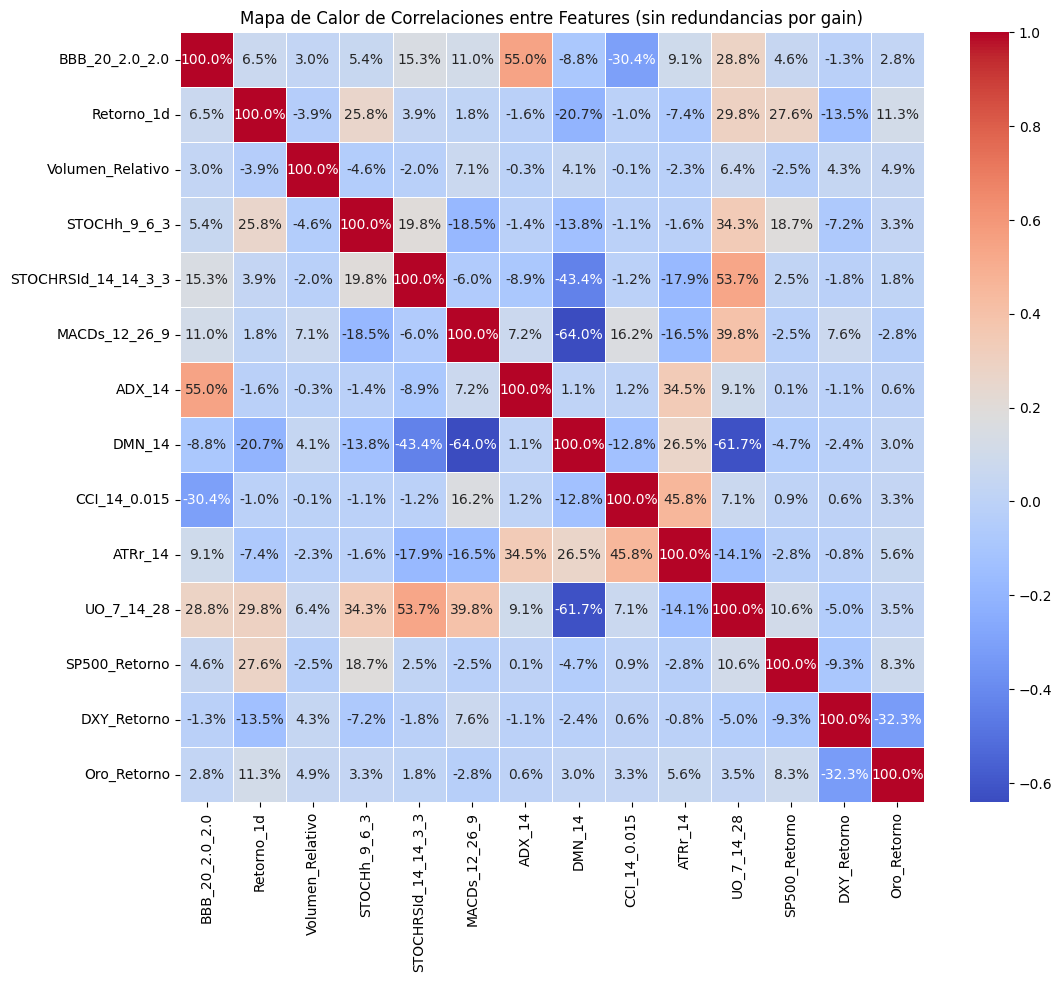

In [25]:
# Correlación entre variables depurando las redundantes
plt.figure(figsize=(12, 10))
sns.heatmap(features_df_std[high_gain_no_redundant].corr('spearman'), annot=True, fmt=".1%", cmap='coolwarm', linewidths=0.5)
plt.title("Mapa de Calor de Correlaciones entre Features (sin redundancias por gain)")
plt.show()

In [26]:
print(f"Total variables seleccionadas por correlación y gain: {len(high_target_corr_no_redundant)}, {len(high_gain_no_redundant)}")

Total variables seleccionadas por correlación y gain: 14, 14


In [27]:
pd.DataFrame({
    'target_corr_vars': high_target_corr_no_redundant,
    'gain_corr_vars': high_gain_no_redundant
})

,target_corr_vars,gain_corr_vars
0,BBB_20_2.0_2.0,BBB_20_2.0_2.0
1,Retorno_1d,Retorno_1d
2,Volumen_Relativo,Volumen_Relativo
3,STOCHd_9_6_3,STOCHh_9_6_3
4,STOCHh_9_6_3,STOCHRSId_14_14_3_3
5,MACD_12_26_9,MACDs_12_26_9
6,ADX_14,ADX_14
7,CCI_14_0.015,DMN_14
8,ATRr_14,CCI_14_0.015
9,BEARP_13,ATRr_14


# Optimización bayesiana
---

## Funciones

In [28]:
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
import xgboost as xgb
import numpy as np

# Función Objetivo que Hyperopt intentará "Minimizar"
def objective_model(params, X_train_data, y_train_data, X_test_data, y_test_data):
    # Hyperopt con quniform devuelve floats, XGBoost exige enteros en estos campos
    max_depth = int(params['max_depth'])
    n_estimators = int(params['n_estimators'])
    umbral = params['umbral']

    modelo_tuning = xgb.XGBClassifier(
        max_depth=max_depth,
        learning_rate=params['learning_rate'],
        subsample=params['subsample'],
        gamma=params['gamma'],
        n_estimators=n_estimators,
        scale_pos_weight=params['scale_pos_weight'],
        early_stopping_rounds=50,
        random_state=42,
        n_jobs=-1
    )

    # Entrenamos pasándole el conjunto de prueba para el Early Stopping
    modelo_tuning.fit(
        X_train_data, y_train_data,
        eval_set=[(X_test_data, y_test_data)],
        verbose=False
    )
    
    # Predecimos probabilidades
    probabilidades = modelo_tuning.predict_proba(X_test_data)
    y_pred_tuning = np.zeros(len(y_test_data))
    
    # Encontramos qué columna de probabilidad corresponde al Mínimo y al Máximo
    idx_minimo = np.where(le.classes_ == -1)[0][0]
    idx_maximo = np.where(le.classes_ == 1)[0][0]

    # Aplicamos el umbral Bayesiano
    for j in range(len(probabilidades)):
        if probabilidades[j][idx_minimo] >= umbral:
            y_pred_tuning[j] = -1
        elif probabilidades[j][idx_maximo] >= umbral:
            y_pred_tuning[j] = 1
            
    # Instanciamos el Backtester con parámetros de riesgo fijos (por ahora)
    bt_temp = tbt.Backtester(df_test_completo, capital_inicial=1000.0)
    retorno, _ = bt_temp.backtest_con_trailing_stop(
        predicciones=y_pred_tuning,
        tamaño_posicion=0.30, 
        stop_loss_inicial=0.03, 
        trailing_activation=0.03, 
        trailing_distancia=0.015
    )

    # Hyperopt minimiza, por lo que devolvemos el retorno negativo
    return {'loss': -retorno, 'status': STATUS_OK}


In [29]:
# Preprocesamiento probabilidades
def preprocesar_probabilidades(parametros, le, X_train_data, y_train_data, X_test_data):
    campeon_max_depth = int(parametros['max_depth'])
    campeon_n_estimators = int(parametros['n_estimators'])
    campeon_umbral = parametros['umbral']

    # 1. Entrenamos al campeón definitivo
    modelo_definitivo = xgb.XGBClassifier(
        max_depth=campeon_max_depth,
        learning_rate=parametros['learning_rate'],
        subsample=parametros['subsample'],
        gamma=parametros['gamma'],
        n_estimators=campeon_n_estimators,
        scale_pos_weight=parametros['scale_pos_weight'],
        random_state=42,
        n_jobs=-1
    )

    modelo_definitivo.fit(X_train_data, y_train_data)
    probabilidades_definitivas = modelo_definitivo.predict_proba(X_test_data)

    y_pred_fijo = np.zeros(len(X_test_data))

    # Encontramos qué columna de probabilidad corresponde al Mínimo y al Máximo
    idx_minimo = np.where(le.classes_ == -1)[0][0]
    idx_maximo = np.where(le.classes_ == 1)[0][0]

    for j in range(len(probabilidades_definitivas)):
        if probabilidades_definitivas[j][idx_minimo] >= campeon_umbral:
            y_pred_fijo[j] = -1
        elif probabilidades_definitivas[j][idx_maximo] >= campeon_umbral:
            y_pred_fijo[j] = 1
    
    return y_pred_fijo

In [30]:
# 3. Función Objetivo del Escudo
def objective_shield(params, proba):
    # Filtro lógico de protección
    if params['trailing_distancia'] >= params['trailing_activation']:
        return {'loss': 0, 'status': STATUS_OK} # Penalizamos combinaciones imposibles
        
    bt_definitivo = tbt.Backtester(df_test_completo, capital_inicial=1000.0)
    retorno, _ = bt_definitivo.backtest_con_trailing_stop(
        predicciones=proba,
        tamaño_posicion=params['tamaño_posicion'],
        stop_loss_inicial=params['stop_loss_inicial'],
        trailing_activation=params['trailing_activation'],
        trailing_distancia=params['trailing_distancia'],
        graficar=False
    )
    return {'loss': -retorno, 'status': STATUS_OK}

## Optimización del modelo con todas las features

In [31]:
print("--- INICIANDO OPTIMIZACIÓN BAYESIANA DEL MODELO (TODAS LAS FEATURES) ---")

# 1. Definimos el espacio de búsqueda Bayesiano para XGBoost
space_modelo = {
    'max_depth': hp.quniform('max_depth', 3, 8, 1),
    'learning_rate': hp.loguniform('learning_rate', -6, -2),
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'gamma': hp.uniform('gamma', 0, 0.5),
    'n_estimators': hp.quniform('n_estimators', 50, 300, 50),
    'scale_pos_weight': hp.uniform('scale_pos_weight', 1, 10),
    'umbral': hp.quniform('umbral', 0.20, 0.35, 0.05),
}

# 2. Ejecutamos la búsqueda
trials_modelo = Trials()

mejores_parametros_modelo = fmin(
    fn=lambda params: objective_model(params, X_train, y_train_xgb, X_test, y_test_xgb),
    space=space_modelo,
    algo=tpe.suggest,
    max_evals=50,
    trials=trials_modelo,
    rstate=np.random.default_rng(42)
)

print("\nMEJORES PARÁMETROS BAYESIANOS (MODELO - TODAS LAS FEATURES):")
print(mejores_parametros_modelo)


--- INICIANDO OPTIMIZACIÓN BAYESIANA DEL MODELO (TODAS LAS FEATURES) ---
  0%|          | 0/50 [00:00<?, ?trial/s, best loss=?]

--- RESULTADOS DEL BACKTEST ---                       
Capital Inicial: $1000.00 USD                         
Capital Final: $1002.27 USD                           
Retorno Total: 0.23%                                  
Total de operaciones cerradas: 5                      
--- RESULTADOS DEL BACKTEST ---                                                   
Capital Inicial: $1000.00 USD                                                     
Capital Final: $1010.78 USD                                                       
Retorno Total: 1.08%                                                              
Total de operaciones cerradas: 17                                                 
--- RESULTADOS DEL BACKTEST ---                                                   
Capital Inicial: $1000.00 USD                                                   
Capital Final: $1005.02 USD                                                     
Retorno Total: 0.50%                                             

## Optimización del modelo con selección por correlación del target

In [32]:
print("--- INICIANDO OPTIMIZACIÓN BAYESIANA DEL MODELO (SELECCIÓN POR CORRELACIÓN) ---")

# Preparar datos con features seleccionadas
X_train_sel = X_train[high_target_corr_no_redundant]
X_test_sel = X_test[high_target_corr_no_redundant]

# 1. Definimos el espacio de búsqueda Bayesiano para XGBoost
space_modelo_sel = {
    'max_depth': hp.quniform('max_depth', 3, 8, 1),
    'learning_rate': hp.loguniform('learning_rate', -6, -2),
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'gamma': hp.uniform('gamma', 0, 0.5),
    'n_estimators': hp.quniform('n_estimators', 50, 300, 50),
    'scale_pos_weight': hp.uniform('scale_pos_weight', 1, 10),
    'umbral': hp.quniform('umbral', 0.20, 0.35, 0.05),
}

# 2. Ejecutamos la búsqueda
trials_modelo_sel = Trials()

mejores_parametros_modelo_sel = fmin(
    fn=lambda params: objective_model(params, X_train_sel, y_train_xgb, X_test_sel, y_test_xgb),
    space=space_modelo_sel,
    algo=tpe.suggest,
    max_evals=50,
    trials=trials_modelo_sel,
    rstate=np.random.default_rng(42)
)

print("\nMEJORES PARÁMETROS BAYESIANOS (MODELO - SELECCIÓN POR CORRELACIÓN):")
print(mejores_parametros_modelo_sel)


--- INICIANDO OPTIMIZACIÓN BAYESIANA DEL MODELO (SELECCIÓN POR CORRELACIÓN) ---
--- RESULTADOS DEL BACKTEST ---                       
Capital Inicial: $1000.00 USD                         
Capital Final: $1012.91 USD                           
Retorno Total: 1.29%                                  
Total de operaciones cerradas: 6                      
--- RESULTADOS DEL BACKTEST ---                                                  
Capital Inicial: $1000.00 USD                                                    
Capital Final: $1010.78 USD                                                      
Retorno Total: 1.08%                                                             
Total de operaciones cerradas: 17                                                
--- RESULTADOS DEL BACKTEST ---                                                  
Capital Inicial: $1000.00 USD                                                    
Capital Final: $980.10 USD                                             

## Optimización del modelo con selección por importancia

In [33]:
print("--- INICIANDO OPTIMIZACIÓN BAYESIANA DEL MODELO (SELECCIÓN POR IMPORTANCIA) ---")

# Preparar datos con features seleccionadas
X_train_gain = X_train[high_gain_no_redundant]
X_test_gain = X_test[high_gain_no_redundant]

# 1. Definimos el espacio de búsqueda Bayesiano para XGBoost
space_modelo_gain = {
    'max_depth': hp.quniform('max_depth', 3, 8, 1),
    'learning_rate': hp.loguniform('learning_rate', -6, -2),
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'gamma': hp.uniform('gamma', 0, 0.5),
    'n_estimators': hp.quniform('n_estimators', 50, 300, 50),
    'scale_pos_weight': hp.uniform('scale_pos_weight', 1, 10),
    'umbral': hp.quniform('umbral', 0.20, 0.35, 0.05),
}

# 2. Ejecutamos la búsqueda
trials_modelo_gain = Trials()

mejores_parametros_modelo_gain = fmin(
    fn=lambda params: objective_model(params, X_train_gain, y_train_xgb, X_test_gain, y_test_xgb),
    space=space_modelo_gain,
    algo=tpe.suggest,
    max_evals=50,
    trials=trials_modelo_gain,
    rstate=np.random.default_rng(42)
)

print("\nMEJORES PARÁMETROS BAYESIANOS (MODELO - SELECCIÓN POR IMPORTANCIA):")
print(mejores_parametros_modelo_gain)


--- INICIANDO OPTIMIZACIÓN BAYESIANA DEL MODELO (SELECCIÓN POR IMPORTANCIA) ---
--- RESULTADOS DEL BACKTEST ---                       
Capital Inicial: $1000.00 USD                         
Capital Final: $1001.39 USD                           
Retorno Total: 0.14%                                  
Total de operaciones cerradas: 7                      
--- RESULTADOS DEL BACKTEST ---                                                   
Capital Inicial: $1000.00 USD                                                     
Capital Final: $1010.78 USD                                                       
Retorno Total: 1.08%                                                              
Total de operaciones cerradas: 17                                                 
--- RESULTADOS DEL BACKTEST ---                                                   
Capital Inicial: $1000.00 USD                                                   
Capital Final: $1006.29 USD                                       

,gamma,learning_rate,max_depth,n_estimators,scale_pos_weight,subsample,umbral
Todas las Features,0.364248,0.047374,4.0,150.0,7.732322,0.932036,0.20
Selección por Correlación,0.309465,0.128948,4.0,150.0,1.943476,0.843261,0.30
Selección por Importancia (Gain),0.006112,0.052866,6.0,250.0,7.343441,0.999933,0.35


In [44]:
brain_results = pd.concat([
    pd.DataFrame(
        {
            'Mejor Retorno Backtest': [
                -min(trials_modelo.losses()), 
                -min(trials_modelo_sel.losses()), 
                -min(trials_modelo_gain.losses())
            ]
        },
        index = ['Todas las Features', 'Selección por Correlación', 'Selección por Importancia (Gain)']
    ),
    pd.concat([
        pd.DataFrame(mejores_parametros_modelo, index=['Todas las Features']),
        pd.DataFrame(mejores_parametros_modelo_sel, index=['Selección por Correlación']),
        pd.DataFrame(mejores_parametros_modelo_gain, index=['Selección por Importancia (Gain)'])
    ])
], axis=1)

print(brain_results)


                                  Mejor Retorno Backtest     gamma  \
Todas las Features                              4.993070  0.364248   
Selección por Correlación                       3.560527  0.309465   
Selección por Importancia (Gain)                7.405893  0.006112   

                                  learning_rate  max_depth  n_estimators  \
Todas las Features                     0.047374        4.0         150.0   
Selección por Correlación              0.128948        4.0         150.0   
Selección por Importancia (Gain)       0.052866        6.0         250.0   

                                  scale_pos_weight  subsample  umbral  
Todas las Features                        7.732322   0.932036    0.20  
Selección por Correlación                 1.943476   0.843261    0.30  
Selección por Importancia (Gain)          7.343441   0.999933    0.35  


## Optimización de la gestión del riesgo

In [41]:
print("\n--- INICIANDO OPTIMIZACIÓN BAYESIANA DEL ESCUDO ---")

# --- ¡IMPORTANTE! --- 
# Aquí debes reemplazar estos valores con los que te arroje el bloque 1
# (Hyperopt te devuelve los valores en un diccionario)
# --------------------
y_pred_final = preprocesar_probabilidades(mejores_parametros_modelo, le, X_train, y_train_xgb, X_test)

# 2. Definimos el espacio de búsqueda Bayesiano para el Escudo (Tus rangos exactos)
space_riesgo = {
    'tamaño_posicion': hp.quniform('tamaño_posicion', 0.10, 0.35, 0.05),
    'stop_loss_inicial': hp.quniform('stop_loss_inicial', 0.03, 0.10, 0.01),
    'trailing_activation': hp.quniform('trailing_activation', 0.03, 0.10, 0.01),
    'trailing_distancia': hp.quniform('trailing_distancia', 0.015, 0.05, 0.005)
}

# 4. Ejecutamos la búsqueda del Escudo
trials_riesgo = Trials()
mejores_parametros_riesgo = fmin(
    fn=lambda params: objective_shield(params, y_pred_final),
    space=space_riesgo,
    algo=tpe.suggest,
    max_evals=100, # Al ser un cálculo rápido sin entrenar modelo, podemos hacer 100 pruebas
    trials=trials_riesgo,
    rstate=np.random.default_rng(42)
)

print("\nMEJORES PARÁMETROS BAYESIANOS (ESCUDO):")
print(mejores_parametros_riesgo)


--- INICIANDO OPTIMIZACIÓN BAYESIANA DEL ESCUDO ---
--- RESULTADOS DEL BACKTEST ---                        
Capital Inicial: $1000.00 USD                          
Capital Final: $957.75 USD                             
Retorno Total: -4.22%                                  
Total de operaciones cerradas: 4                       
--- RESULTADOS DEL BACKTEST ---                        
Capital Inicial: $1000.00 USD                                                   
Capital Final: $1021.71 USD                                                     
Retorno Total: 2.17%                                                            
Total de operaciones cerradas: 7                                                
--- RESULTADOS DEL BACKTEST ---                                                   
Capital Inicial: $1000.00 USD                                                     
Capital Final: $1028.27 USD                                                       
Retorno Total: 2.83%                  

## Optimización de la gestión del riesgo con selección por correlación

In [42]:
print("\n--- INICIANDO OPTIMIZACIÓN BAYESIANA DEL ESCUDO (SELECCIÓN POR CORRELACIÓN) ---")


y_pred_sel = preprocesar_probabilidades(mejores_parametros_modelo_sel, le, X_train_sel, y_train_xgb, X_test_sel)

# 2. Definimos el espacio de búsqueda Bayesiano para el Escudo (Tus rangos exactos)
space_riesgo_sel = {
    'tamaño_posicion': hp.quniform('tamaño_posicion', 0.10, 0.35, 0.05),
    'stop_loss_inicial': hp.quniform('stop_loss_inicial', 0.03, 0.10, 0.01),
    'trailing_activation': hp.quniform('trailing_activation', 0.03, 0.10, 0.01),
    'trailing_distancia': hp.quniform('trailing_distancia', 0.015, 0.05, 0.005)
}

# 4. Ejecutamos la búsqueda del Escudo
trials_riesgo_sel = Trials()
mejores_parametros_riesgo_sel = fmin(
    fn=lambda params: objective_shield(params, y_pred_sel),
    space=space_riesgo_sel,
    algo=tpe.suggest,
    max_evals=100, # Al ser un cálculo rápido sin entrenar modelo, podemos hacer 100 pruebas
    trials=trials_riesgo_sel,
    rstate=np.random.default_rng(42)
)

print("\nMEJORES PARÁMETROS BAYESIANOS (ESCUDO):")
print(mejores_parametros_riesgo_sel)


--- INICIANDO OPTIMIZACIÓN BAYESIANA DEL ESCUDO (SELECCIÓN POR CORRELACIÓN) ---
--- RESULTADOS DEL BACKTEST ---                        
Capital Inicial: $1000.00 USD                          
Capital Final: $986.69 USD                             
Retorno Total: -1.33%                                  
Total de operaciones cerradas: 4                       
--- RESULTADOS DEL BACKTEST ---                        
Capital Inicial: $1000.00 USD                                                    
Capital Final: $1014.30 USD                                                      
Retorno Total: 1.43%                                                             
Total de operaciones cerradas: 6                                                 
--- RESULTADOS DEL BACKTEST ---                                                   
Capital Inicial: $1000.00 USD                                                     
Capital Final: $1036.43 USD                                                       
Retorn

## Optimización de la gestión del riesgo con selección por importancia

In [43]:
print("\n--- INICIANDO OPTIMIZACIÓN BAYESIANA DEL ESCUDO (SELECCIÓN POR IMPORTANCIA) ---")


y_pred_gain = preprocesar_probabilidades(mejores_parametros_modelo_gain, le, X_train_gain, y_train_xgb, X_test_gain)

# 2. Definimos el espacio de búsqueda Bayesiano para el Escudo (Tus rangos exactos)
space_riesgo_gain = {
    'tamaño_posicion': hp.quniform('tamaño_posicion', 0.10, 0.35, 0.05),
    'stop_loss_inicial': hp.quniform('stop_loss_inicial', 0.03, 0.10, 0.01),
    'trailing_activation': hp.quniform('trailing_activation', 0.03, 0.10, 0.01),
    'trailing_distancia': hp.quniform('trailing_distancia', 0.015, 0.05, 0.005)
}

# 4. Ejecutamos la búsqueda del Escudo
trials_riesgo_gain = Trials()
mejores_parametros_riesgo_gain = fmin(
    fn=lambda params: objective_shield(params, y_pred_gain),
    space=space_riesgo_gain,
    algo=tpe.suggest,
    max_evals=100, # Al ser un cálculo rápido sin entrenar modelo, podemos hacer 100 pruebas
    trials=trials_riesgo_gain,
    rstate=np.random.default_rng(42)
)

print("\nMEJORES PARÁMETROS BAYESIANOS (ESCUDO):")
print(mejores_parametros_riesgo_gain)


--- INICIANDO OPTIMIZACIÓN BAYESIANA DEL ESCUDO (SELECCIÓN POR IMPORTANCIA) ---
--- RESULTADOS DEL BACKTEST ---                        
Capital Inicial: $1000.00 USD                          
Capital Final: $957.94 USD                             
Retorno Total: -4.21%                                  
Total de operaciones cerradas: 3                       
--- RESULTADOS DEL BACKTEST ---                        
Capital Inicial: $1000.00 USD                                                   
Capital Final: $1006.51 USD                                                     
Retorno Total: 0.65%                                                            
Total de operaciones cerradas: 4                                                
--- RESULTADOS DEL BACKTEST ---                                                   
Capital Inicial: $1000.00 USD                                                     
Capital Final: $1001.73 USD                                                       
Retorno To

In [45]:
shield_results = pd.concat([
    pd.DataFrame(
        {
            'Mejor Retorno Backtest': [
                -min(trials_riesgo.losses()), 
                -min(trials_riesgo_sel.losses()), 
                -min(trials_riesgo_gain.losses())
            ]
        },
        index = ['Todas las Features', 'Selección por Correlación', 'Selección por Importancia (Gain)']
    ),
    pd.concat([
        pd.DataFrame(mejores_parametros_riesgo, index=['Todas las Features']),
        pd.DataFrame(mejores_parametros_riesgo_sel, index=['Selección por Correlación']),
        pd.DataFrame(mejores_parametros_riesgo_gain, index=['Selección por Importancia (Gain)'])
    ])
], axis=1)

print(shield_results)


                                  Mejor Retorno Backtest  stop_loss_inicial  \
Todas las Features                              5.828061               0.03   
Selección por Correlación                       6.845740               0.06   
Selección por Importancia (Gain)                1.205982               0.03   

                                  tamaño_posicion  trailing_activation  \
Todas las Features                           0.35                 0.03   
Selección por Correlación                    0.35                 0.03   
Selección por Importancia (Gain)             0.35                 0.08   

                                  trailing_distancia  
Todas las Features                             0.015  
Selección por Correlación                      0.015  
Selección por Importancia (Gain)               0.035  


## Mejores parámetros
---

In [60]:
resultados_finales = pd.concat([
    brain_results.rename(columns={'Mejor Retorno Backtest':'Retorno Backtest Modelo'}),
    shield_results.rename(columns={'Mejor Retorno Backtest':'Retorno Backtest Escudo'})
], axis=1)

resultados_finales.T

,Todas las Features,Selección por Correlación,Selección por Importancia (Gain)
Retorno Backtest Modelo,4.993070,3.560527,7.405893
gamma,0.364248,0.309465,0.006112
learning_rate,0.047374,0.128948,0.052866
max_depth,4.000000,4.000000,6.000000
n_estimators,150.000000,150.000000,250.000000
scale_pos_weight,7.732322,1.943476,7.343441
subsample,0.932036,0.843261,0.999933
umbral,0.200000,0.300000,0.350000
Retorno Backtest Escudo,5.828061,6.845740,1.205982
stop_loss_inicial,0.030000,0.060000,0.030000


--- RESULTADOS DEL BACKTEST ---
Capital Inicial: $1000.00 USD
Capital Final: $1068.46 USD
Retorno Total: 6.85%
Total de operaciones cerradas: 6


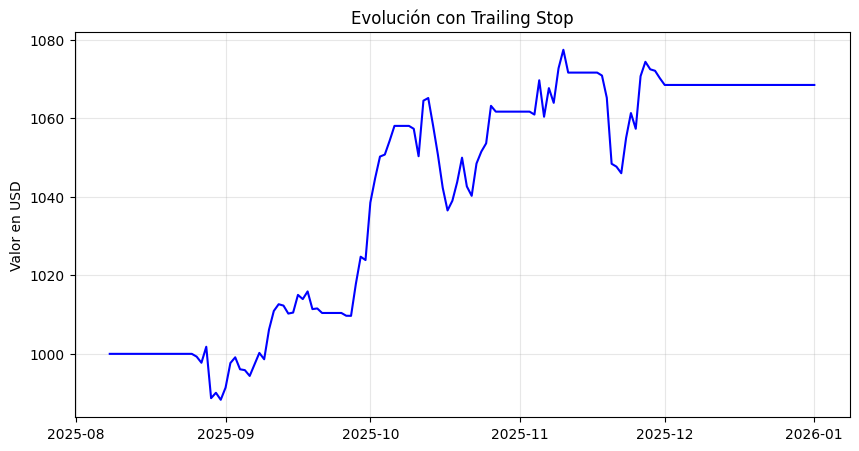

(np.float64(6.845740091414404),
         Fecha                   Tipo        Precio      Capital
 0  2025-08-26                 Compra  111763.22000   999.650000
 1  2025-09-21  Venta (Trailing Stop)  115317.42705  1010.408528
 2  2025-09-26                 Compra  109643.46000  1010.054885
 3  2025-10-06   Venta (Señal Modelo)  124658.54000  1058.034283
 4  2025-10-10                 Compra  112774.50000  1057.663971
 5  2025-10-27   Venta (Señal Modelo)  114107.65000  1061.662877
 6  2025-11-04                 Compra  101497.22000  1061.291295
 7  2025-11-11  Venta (Trailing Stop)  104420.96305  1071.602530
 8  2025-11-18                 Compra   92960.83000  1071.227470
 9  2025-11-20   Venta (Stop Inicial)   87383.18020  1048.394115
 10 2025-11-21                 Compra   85129.43000  1048.027177
 11 2025-12-01  Venta (Trailing Stop)   89963.94075  1068.457401)

In [48]:
tbt.Backtester(df_test_completo, capital_inicial=1000.0).backtest_con_trailing_stop(
        predicciones=y_pred_sel,
        tamaño_posicion=mejores_parametros_riesgo_sel['tamaño_posicion'],
        stop_loss_inicial=mejores_parametros_riesgo_sel['stop_loss_inicial'],
        trailing_activation=mejores_parametros_riesgo_sel['trailing_activation'],
        trailing_distancia=mejores_parametros_riesgo_sel['trailing_distancia'],
        graficar=True
    )

In [49]:
X_test.index.values.min(), X_test.index.values.max()

(np.datetime64('2025-08-08T00:00:00.000000000'),
 np.datetime64('2026-01-01T00:00:00.000000000'))

# Out-of-time validation
---

### Carga de datos OOT

In [53]:
# Cargamos los datos desde la carpeta data y si no existen, ejecutamos el pipeline
try: 
    os.chdir('..')
    os.chdir('data/processed')
    df_oot = pd.read_csv('ccxt_btc_data_oot.csv', index_col=0)
    print("Datos cargados desde 'data/processed/ccxt_btc_data_oot.csv'")

except FileNotFoundError:
    print("Archivo no encontrado. Ejecutando el pipeline para generar los datos...")

    # 1. Instanciar la clase (Configuramos las variables globales del proceso)
    extractor_ccxt = ccxt.ExtractorDatosCCXT(
        exchange_id='binance', 
        symbol='BTC/USDT', 
        timeframe='1d', 
        ventana_critica=5
    )

    # 2. Ejecutar las transformaciones en cadena (Pipeline)
    # Cada paso toma el DataFrame del paso anterior, lo transforma y lo devuelve

    # Paso A: Obtener el precio histórico y volumen
    df_base_oot = extractor_ccxt.obtener_datos(
        start_date="2026-01-02",
        end_date="2026-03-30",
        buffer_dias=34
    )

    # Paso B: Etiquetar máximos y mínimos (Nuestro Target)
    df_etiquetado_oot = extractor_ccxt.etiquetar_puntos_criticos(df_base_oot)

    # Paso C: Calcular todo el análisis técnico
    df_con_indicadores_oot = extractor_ccxt.agregar_indicadores_avanzados(df_etiquetado_oot)

    # Paso D: Enriquecer con datos macroeconómicos
    df_oot = extractor_ccxt.agregar_contexto_macro(df_con_indicadores_oot)

    # 3. Revisar el resultado final
    print("\n--- Vista previa de las primeras 5 filas ---")
    print(df_oot.head())

    # Creamos el archivo en la carpeta data/processed
    os.chdir(CURRENT_DIR)
    os.chdir('..')
    os.makedirs('data/processed', exist_ok=True)
    df_oot.to_csv('data/processed/ccxt_btc_data_oot.csv', index=True)
    
    print("Datos generados y guardados en 'data/processed/ccxt_btc_data_oot.csv'")

finally:
    os.chdir(CURRENT_DIR) 


Archivo no encontrado. Ejecutando el pipeline para generar los datos...
[CCXT] Descargando BTC/USDT desde 2025-11-29...
Iniciando descarga de datos macroeconómicos...
-> Descargando SP500 (^GSPC)...
-> Descargando DXY (DX-Y.NYB)...
-> Descargando Oro (GC=F)...

¡Contexto macro agregado exitosamente!

--- Vista previa de las primeras 5 filas ---
                Open      High       Low     Close       Volume  Retorno_Log  \
Date                                                                           
2026-01-02  88839.05  90961.81  88379.88  89995.13  17396.97301     0.012929   
2026-01-03  89995.14  90741.16  89314.01  90628.01   7057.46716     0.007008   
2026-01-04  90628.01  91810.00  90628.00  91529.73  10426.52970     0.009901   
2026-01-05  91529.74  94789.08  91514.81  93859.71  20673.59584     0.025137   
2026-01-06  93859.71  94444.44  91262.94  93747.97  18546.41829    -0.001191   

            Target     RSI_14  BBL_20_2.0_2.0  BBM_20_2.0_2.0  ...    ROC_10  \
Date        

### Backtesting

In [54]:
df_oot.index.values.min(), df_oot.index.values.max()

(np.datetime64('2026-01-02T00:00:00.000000000'),
 np.datetime64('2026-03-30T00:00:00.000000000'))

3. Generando predicciones con el modelo campeón...
   -> Señales generadas: 14 alertas detectadas.
4. Ejecutando Backtester con Gestión de Riesgo Óptima...
--- RESULTADOS DEL BACKTEST ---
Capital Inicial: $1000.00 USD
Capital Final: $1019.70 USD
Retorno Total: 1.97%
Total de operaciones cerradas: 5


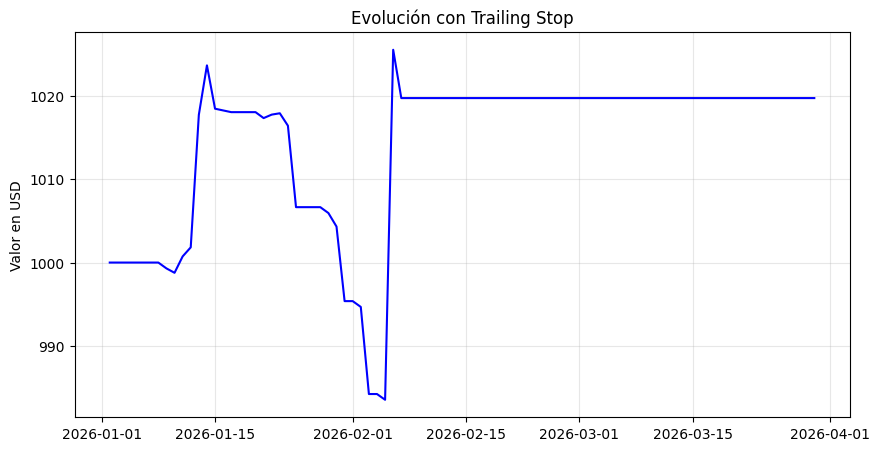


Historial de Operaciones en el OOT:
       Fecha                   Tipo      Precio      Capital
0 2026-01-09                 Compra  90641.2800   999.650000
1 2026-01-17  Venta (Trailing Stop)  95497.5033  1018.014566
2 2026-01-21                 Compra  89454.7300  1017.658261
3 2026-01-25   Venta (Stop Inicial)  86771.0881  1006.634527
4 2026-01-29                 Compra  84650.1600  1006.282205
5 2026-01-31   Venta (Stop Inicial)  82110.6552   995.381701
6 2026-02-02                 Compra  78738.6100   995.033318
7 2026-02-03   Venta (Stop Inicial)  76376.4517   984.254667
8 2026-02-05                 Compra  62909.8600   983.910178
9 2026-02-07  Venta (Trailing Stop)  69521.5561  1019.698754


In [55]:
X_oot = df_oot[features]

# --- 3. PREDICCIÓN A CIEGAS ---
print("3. Generando predicciones con el modelo campeón...")

y_pred_oot = preprocesar_probabilidades(mejores_parametros_modelo, le, X_train, y_train_xgb, X_oot)

print(f"   -> Señales generadas: {np.sum(y_pred_oot != 0)} alertas detectadas.")

# --- 4. BACKTESTING FINAL ---
print("4. Ejecutando Backtester con Gestión de Riesgo Óptima...")
bt_oot = tbt.Backtester(df_oot, capital_inicial=1000.0)

retorno_oot, trades_oot = bt_oot.backtest_con_trailing_stop(
    predicciones=y_pred_oot,
    tamaño_posicion=mejores_parametros_riesgo['tamaño_posicion'],        # ¡El 35% dictado por Hyperopt!
    stop_loss_inicial=mejores_parametros_riesgo['stop_loss_inicial'],      # 3%
    trailing_activation=mejores_parametros_riesgo['trailing_activation'],    # 3%
    trailing_distancia=mejores_parametros_riesgo['trailing_distancia'],    # 1.5%
    graficar=True                # Queremos ver la curva de capital final
)

# Opcional: Mostrar los trades si hubo operaciones
if not trades_oot.empty:
    print("\nHistorial de Operaciones en el OOT:")
    print(trades_oot[['Fecha', 'Tipo', 'Precio', 'Capital']])

3. Generando predicciones con el modelo campeón...
   -> Señales generadas: 11 alertas detectadas.
4. Ejecutando Backtester con Gestión de Riesgo Óptima...
--- RESULTADOS DEL BACKTEST ---
Capital Inicial: $1000.00 USD
Capital Final: $991.62 USD
Retorno Total: -0.84%
Total de operaciones cerradas: 3


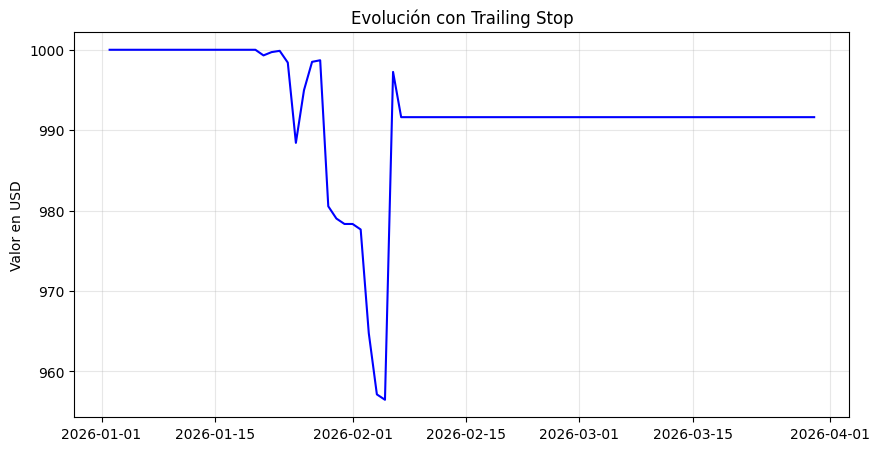


Historial de Operaciones en el OOT:
       Fecha                   Tipo      Precio     Capital
0 2026-01-21                 Compra  89454.7300  999.650000
1 2026-01-31   Venta (Stop Inicial)  84087.4462  978.342329
2 2026-02-02                 Compra  78738.6100  977.999909
3 2026-02-04   Venta (Stop Inicial)  74014.2934  957.153713
4 2026-02-05                 Compra  62909.8600  956.818709
5 2026-02-07  Venta (Trailing Stop)  69521.5561  991.621865


In [56]:
X_oot_sel = df_oot[high_target_corr_no_redundant]

# --- 3. PREDICCIÓN A CIEGAS ---
print("3. Generando predicciones con el modelo campeón...")

y_pred_oot_sel = preprocesar_probabilidades(mejores_parametros_modelo_sel, le, X_train_sel, y_train_xgb, X_oot_sel)

print(f"   -> Señales generadas: {np.sum(y_pred_oot_sel != 0)} alertas detectadas.")

# --- 4. BACKTESTING FINAL ---
print("4. Ejecutando Backtester con Gestión de Riesgo Óptima...")
bt_oot_sel = tbt.Backtester(df_oot, capital_inicial=1000.0)

retorno_oot_sel, trades_oot_sel = bt_oot_sel.backtest_con_trailing_stop(
    predicciones=y_pred_oot_sel,
    tamaño_posicion=mejores_parametros_riesgo_sel['tamaño_posicion'],        # ¡El 35% dictado por Hyperopt!
    stop_loss_inicial=mejores_parametros_riesgo_sel['stop_loss_inicial'],      # 3%
    trailing_activation=mejores_parametros_riesgo_sel['trailing_activation'],    # 3%
    trailing_distancia=mejores_parametros_riesgo_sel['trailing_distancia'],    # 1.5%
    graficar=True                # Queremos ver la curva de capital final
)

# Opcional: Mostrar los trades si hubo operaciones
if not trades_oot_sel.empty:
    print("\nHistorial de Operaciones en el OOT:")
    print(trades_oot_sel[['Fecha', 'Tipo', 'Precio', 'Capital']])

3. Generando predicciones con el modelo campeón...
   -> Señales generadas: 9 alertas detectadas.
4. Ejecutando Backtester con Gestión de Riesgo Óptima...
--- RESULTADOS DEL BACKTEST ---
Capital Inicial: $1000.00 USD
Capital Final: $971.98 USD
Retorno Total: -2.80%
Total de operaciones cerradas: 6


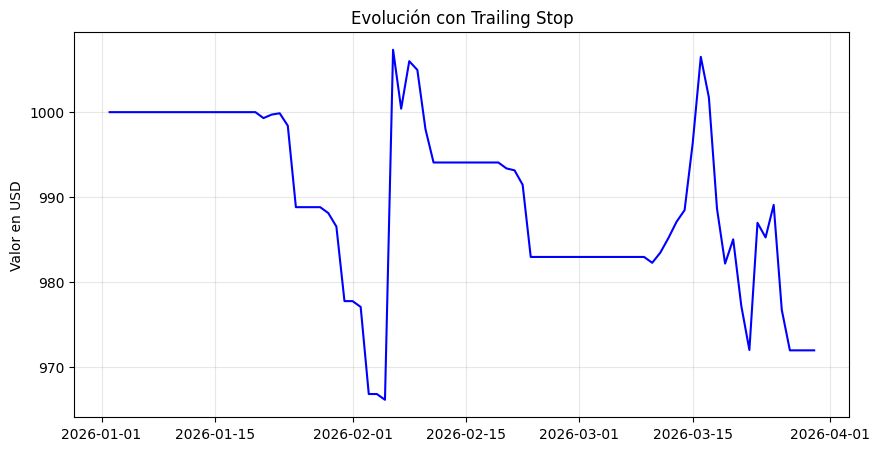


Historial de Operaciones en el OOT:
        Fecha                   Tipo      Precio     Capital
0  2026-01-21                 Compra  89454.7300  999.650000
1  2026-01-25   Venta (Stop Inicial)  86771.0881  988.821340
2  2026-01-29                 Compra  84650.1600  988.475252
3  2026-01-31   Venta (Stop Inicial)  82110.6552  977.767641
4  2026-02-02                 Compra  78738.6100  977.425423
5  2026-02-03   Venta (Stop Inicial)  76376.4517  966.837509
6  2026-02-05                 Compra  62909.8600  966.499116
7  2026-02-11  Venta (Trailing Stop)  68109.9509  994.076517
8  2026-02-20                 Compra  68020.0100  993.728590
9  2026-02-23   Venta (Stop Inicial)  65979.4097  982.964073
10 2026-03-10                 Compra  69948.6300  982.620036
11 2026-03-27   Venta (Stop Inicial)  67850.1711  971.975852


In [57]:
X_oot_g = df_oot[high_gain_no_redundant]

# --- 3. PREDICCIÓN A CIEGAS ---
print("3. Generando predicciones con el modelo campeón...")

y_pred_oot_g = preprocesar_probabilidades(mejores_parametros_modelo_gain, le, X_train_gain, y_train_xgb, X_oot_g)

print(f"   -> Señales generadas: {np.sum(y_pred_oot_g != 0)} alertas detectadas.")

# --- 4. BACKTESTING FINAL ---
print("4. Ejecutando Backtester con Gestión de Riesgo Óptima...")
bt_oot_g = tbt.Backtester(df_oot, capital_inicial=1000.0)

retorno_oot_g, trades_oot_g = bt_oot_g.backtest_con_trailing_stop(
    predicciones=y_pred_oot_g,
    tamaño_posicion=mejores_parametros_riesgo_gain['tamaño_posicion'],        # ¡El 35% dictado por Hyperopt!
    stop_loss_inicial=mejores_parametros_riesgo_gain['stop_loss_inicial'],      # 3%
    trailing_activation=mejores_parametros_riesgo_gain['trailing_activation'],    # 3%
    trailing_distancia=mejores_parametros_riesgo_gain['trailing_distancia'],    # 1.5%
    graficar=True                # Queremos ver la curva de capital final
)

# Opcional: Mostrar los trades si hubo operaciones
if not trades_oot_g.empty:
    print("\nHistorial de Operaciones en el OOT:")
    print(trades_oot_g[['Fecha', 'Tipo', 'Precio', 'Capital']])

# Extracción y serialización del modelo final
---

In [69]:
import joblib
import os

def save_production_model(model, feature_names, umbral, save_path, curr_dir):
    """
    Guarda el modelo de Machine Learning listo para producción.
    Excluye datos de entrenamiento (X, y) para mantener el archivo ligero.
    """
    # Empaquetamos solo lo estrictamente necesario para operar
    objeto_a_guardar = {
        'modelo': model,
        'feature_names': list(feature_names), # Guardamos el orden exacto de las columnas
        'umbral_decision': umbral             # El umbral Bayesiano (ej. 0.25)
    }

    # Crear carpeta si no existe
    os.chdir('..')
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    # Guardar con joblib comprimido (compress=3 reduce el peso del archivo)
    joblib.dump(objeto_a_guardar, save_path, compress=3)
    
    print(f"Modelo de producción empaquetado con éxito en: {save_path}")
    print(f"Features guardadas: {len(feature_names)}")
    print(f"Umbral de decisión configurado en: {umbral}")
    os.chdir(curr_dir)  # Volvemos al directorio original

In [62]:
# 1. Entrenamos al campeón definitivo
modelo_definitivo = xgb.XGBClassifier(
    max_depth=int(mejores_parametros_modelo['max_depth']),
    learning_rate=mejores_parametros_modelo['learning_rate'],
    subsample=mejores_parametros_modelo['subsample'],
    gamma=mejores_parametros_modelo['gamma'],
    n_estimators=int(mejores_parametros_modelo['n_estimators']),
    scale_pos_weight=mejores_parametros_modelo['scale_pos_weight'],
    random_state=42,
    n_jobs=-1
)

modelo_definitivo.fit(X_train, y_train_xgb)

print(f"Umbral de decisión óptimo encontrado: {mejores_parametros_modelo['umbral']}")

Umbral de decisión óptimo encontrado: 0.2


In [70]:
save_production_model(
    model=modelo_definitivo, 
    feature_names=X_train.columns, 
    umbral=mejores_parametros_modelo['umbral'],
    save_path='models/apex_xgb_model_v1.pkl',
    curr_dir=CURRENT_DIR
)

Modelo de producción empaquetado con éxito en: models/apex_xgb_model_v1.pkl
Features guardadas: 30
Umbral de decisión configurado en: 0.2
